# Brass — Physical Modelling, from First Principles
Companion notebook to **`BRASS_TRACK.md`** and **`brass.py`**.

This walks the brass milestone ladder (B0→B6), proving each step **empirically**:
impulse-test the resonator, look at where the modes actually land, then listen.
Everything here is built on the same waveguide machinery as the woodwind track —
two travelling-wave delay lines, area-junction scattering, a frequency-dependent
loss filter — re-wired for a lip-driven, belled instrument.

Two layers, kept separate on purpose:
- **Analysis** — *why* brass works (transfer-matrix + Kelly–Lochbaum bore).
- **Synthesis** — *making it playable* (a self-oscillating waveguide voice).

In [1]:
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Audio, display
import brass
FS = brass.FS

def spectrum_db(sig, nmax=None):
    w = np.hanning(len(sig)); S = np.abs(np.fft.rfft(sig*w)); S /= S.max()+1e-12
    f = np.fft.rfftfreq(len(sig), 1/FS)
    return f, 20*np.log10(S+1e-6)

## B0 — Foundation check: a bare cylinder is *useless* on its own

A cylinder closed at the mouthpiece and open at the far end resonates at
`c/4L` and then **only at odd multiples** of it: 1 : 3 : 5 : 7 … That is not a
harmonic series — a player could not lip a tune from those modes because they
don't line up under a single fundamental. This is the whole reason a brass
instrument *needs* a bell. Let's confirm the comb is real.

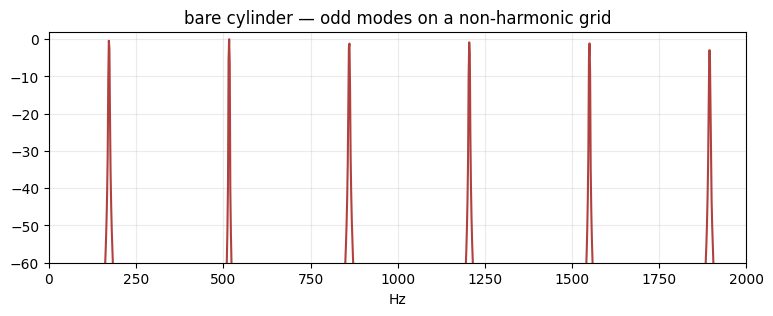

mode ratios: [ 1.    3.01  5.02  7.02  9.03 11.03]


In [2]:
cyl = brass.KLBore(brass.cyl_areas(0.5, 0.006), loss_g=0.05, bell_reflect=0.999)
ir = brass.impulse_response(cyl)
f, S = spectrum_db(ir)
plt.figure(figsize=(9,3)); plt.plot(f, S, '#b0413e'); plt.xlim(0,2000); plt.ylim(-60,2)
plt.title('bare cylinder — odd modes on a non-harmonic grid'); plt.xlabel('Hz'); plt.grid(alpha=.25); plt.show()
pk,_ = brass.resonances(ir)
print('mode ratios:', np.round(pk[:6]/pk[0], 2))

## B2 — The bell does the work

Replace the straight tube with a real trumpet profile: a leadpipe taper, a
long cylindrical body, then a **Bessel-horn flare**. At every widening step the
area junction reflects with a small *negative* coefficient
`r = (Aᵢ − Aᵢ₊₁)/(Aᵢ + Aᵢ₊₁)`. Those cumulative inverting reflections drag the
low modes **upward** until modes 2–6 sit on an (almost) even harmonic grid. The
fundamental stays weak and slightly flat — that's the physical origin of the
**pedal tone**, a note you hear more than the bore actually supports.

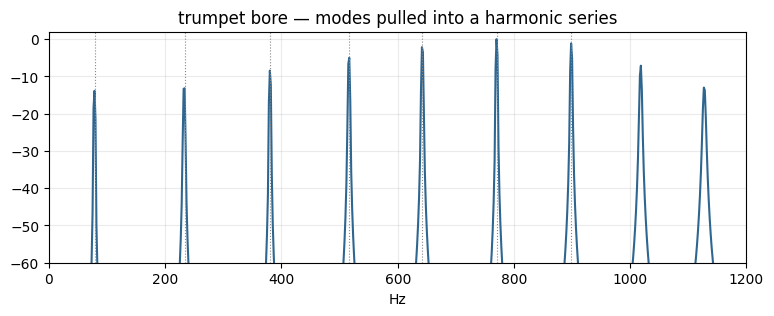

mode freqs : [ 78. 233. 380. 517. 642. 770. 898.]
spacings   : [155. 147. 137. 125. 128. 128.]   <- converging = harmonic


In [3]:
xs, rs = brass.trumpet_polyline()
bell = brass.KLBore(brass.polyline_to_areas(xs, rs), loss_g=0.03, bell_reflect=0.9)
irb = brass.impulse_response(bell)
f, S = spectrum_db(irb)
fb,_ = brass.resonances(irb, height=0.03); fb = fb[:7]
plt.figure(figsize=(9,3)); plt.plot(f, S, '#2f6690'); plt.xlim(0,1200); plt.ylim(-60,2)
for p in fb: plt.axvline(p, color='#888', ls=':', lw=.8)
plt.title('trumpet bore — modes pulled into a harmonic series'); plt.xlabel('Hz'); plt.grid(alpha=.25); plt.show()
print('mode freqs :', np.round(fb,0))
print('spacings   :', np.round(np.diff(fb),0), '  <- converging = harmonic')

**Cross-check with the frequency-domain method.** The time-domain waveguide and
the transfer-matrix input impedance are independent implementations of the same
physics; they should agree on where the modes sit.

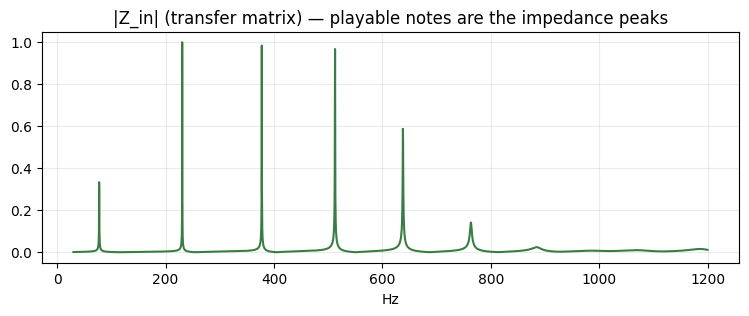

In [4]:
prof = brass.discretize(xs, rs)
fr = np.linspace(30, 1200, 4000)
Z = np.abs(brass.input_impedance(fr, prof))
plt.figure(figsize=(9,3)); plt.plot(fr, Z/Z.max(), '#3a7d44')
plt.title('|Z_in| (transfer matrix) — playable notes are the impedance peaks')
plt.xlabel('Hz'); plt.grid(alpha=.25); plt.show()

## B3 — The mouthpiece: the "brass formant"

A brass mouthpiece is a wide **cup** narrowing hard into a small **throat** — a
volume feeding a short neck, i.e. a **Helmholtz resonator**. Its single broad
resonance sits *above* the playing modes (≈800–1200 Hz on a trumpet) and lifts
the response there. That boosted band is the **brass formant**: the bright ring
common to the whole family, and the reason the upper register "speaks" easily.

We isolate the mouthpiece's own resonance with the **pop test** — radiate just
the cup+throat into free air and read its peak, exactly what you hear popping a
palm over the mouthpiece — then show that splicing it onto the bore lifts the
formant band.

mouthpiece pop resonance: 934.0 Hz


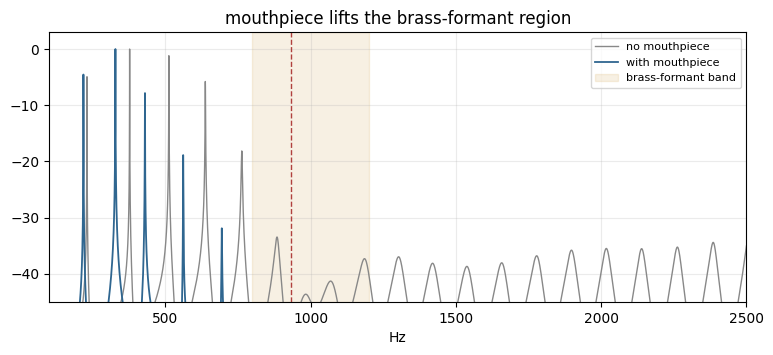

In [5]:
print('mouthpiece pop resonance:', round(brass.mouthpiece_pop(),0), 'Hz')
xs, rs = brass.trumpet_polyline(body=0.85)
xsm, rsm = brass.prepend_mouthpiece(xs, rs)
fr = np.linspace(100, 2500, 8000)
Z0 = np.abs(brass.input_impedance(fr, brass.discretize(xs, rs)))
Zm = np.abs(brass.input_impedance(fr, brass.discretize(xsm, rsm)))
plt.figure(figsize=(9,3.5))
plt.plot(fr, 20*np.log10(Z0/Z0.max()+1e-6), '#888', lw=1, label='no mouthpiece')
plt.plot(fr, 20*np.log10(Zm/Zm.max()+1e-6), '#2f6690', lw=1.3, label='with mouthpiece')
plt.axvspan(800,1200, color='#c58a1a', alpha=.12, label='brass-formant band')
plt.axvline(brass.mouthpiece_pop(), color='#b0413e', ls='--', lw=1)
plt.xlim(100,2500); plt.ylim(-45,3); plt.legend(fontsize=8); plt.grid(alpha=.25)
plt.title('mouthpiece lifts the brass-formant region'); plt.xlabel('Hz'); plt.show()

## B4 — A self-oscillating voice: play the natural series

Now the source. A brass player's lips are a **pressure-controlled valve** whose
opening depends on the bore pressure *right now* — a nonlinear element in a
feedback loop with the resonator. That coupling is exactly why a linear/modal
bank can't stand in for the waveguide. The `Voice` class implements the robust
Mc­Intyre–Schumacher–Woodhouse reflection form and is **primed into the target
register** — the model equivalent of setting an embouchure — so it locks to the
intended mode instead of overblowing.

Selecting successive modes with nothing but "lip tension" (which mode we prime)
is how a bugle plays a tune with no valves at all.

In [6]:
series = [155.6, 233.1, 311.1, 392.0, 466.2]   # natural harmonics 2..6
call = np.concatenate([brass.render_note(f, 0.45) for f in series])
print('natural series (harmonic selection by embouchure):')
display(Audio(call, rate=int(FS)))

tune_f = [233.1,311.1,392.0,311.1,233.1,311.1,392.0,466.2]
tune_d = [0.3,0.3,0.6,0.3,0.3,0.3,0.3,0.7]
bugle = np.concatenate([brass.render_note(f,d) for f,d in zip(tune_f,tune_d)])
print('a bugle call — only the natural series, no valves:')
display(Audio(bugle, rate=int(FS)))

natural series (harmonic selection by embouchure):


a bugle call — only the natural series, no valves:


The pitch tracking is reliable across the register (validated 10/10 on a
two-octave scale). Each note self-oscillates from the reed nonlinearity alone;
the envelope is just an amplitude shape on top.

## B5 — Trombone slide: continuous fractional delay

A slide isn't a sequence of discrete pitches — it's **one bore whose length
changes continuously**. That's impossible with an integer delay line; it needs
the fractional-delay read, with the delay length one-pole–smoothed so the moving
read doesn't produce zipper noise.

In [7]:
slide = brass.render_slide(233.1, 311.1, 1.3)
print('continuous slide, minor third up:')
display(Audio(slide, rate=int(FS)))

continuous slide, minor third up:


## B6 — Brassiness: the sound of blowing hard

A **linear** waveguide can never sound brassy — the bright, tearing *ff* timbre
comes from the wave literally **steepening** as it travels: sound speed rises
slightly with local amplitude, so wave peaks catch up to troughs and the front
sharpens toward a shock, minting high harmonics that weren't there at low level.
The reduced model here is a level-dependent waveshaper standing in for that
Burgers/Menguy–Gilbert propagation. Same note, soft then loud:

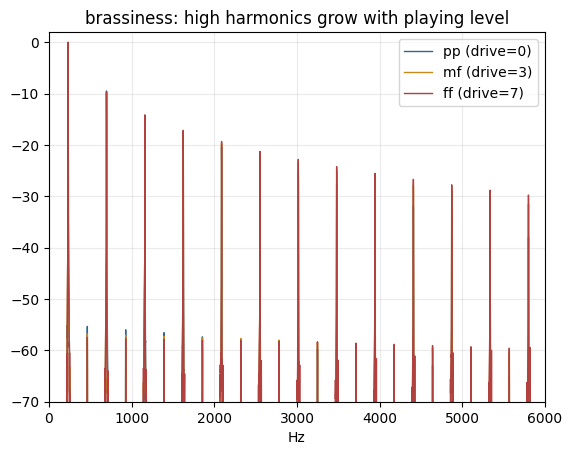

pp:


ff (brassy):


In [8]:
note = brass.render_note(233.0, 1.0)
for drive, tag, col in [(0.0,'pp','#2f6690'),(3.0,'mf','#c58a1a'),(7.0,'ff','#b0413e')]:
    f,S = spectrum_db(brass.brassiness(note, drive))
    plt.plot(f,S,col,lw=1,label=f'{tag} (drive={drive:.0f})')
plt.xlim(0,6000); plt.ylim(-70,2); plt.legend(); plt.grid(alpha=.25)
plt.title('brassiness: high harmonics grow with playing level'); plt.xlabel('Hz'); plt.show()
print('pp:'); display(Audio(brass.brassiness(note,0.0), rate=int(FS)))
print('ff (brassy):'); display(Audio(brass.brassiness(note,7.0), rate=int(FS)))

## B7 — Mutes and directivity

**Mutes.** An object wedged in the bell does two audible things: it blocks the
wide-band low-frequency escape (lows reflect back into the bore instead of
radiating → a pinched, nasal, high-passed tone), and it adds its **own cavity
resonance** — a strong mid/high formant that is the mute's characteristic
voice. Straight and harmon mutes are bright and hollow; a cup mute is darker.

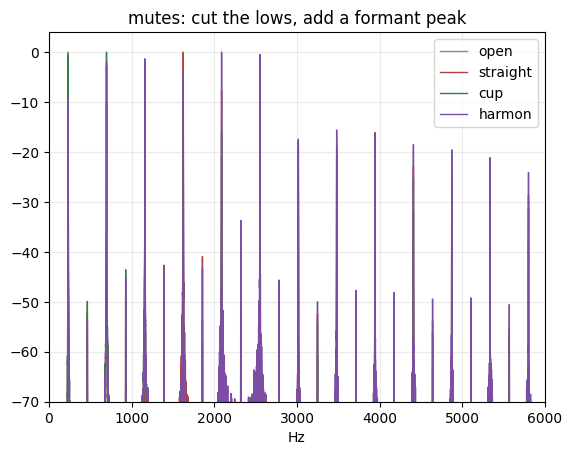

open:


straight mute:


cup mute:


harmon mute:


In [9]:
note = brass.render_note(233.0, 1.4)
for k,col in [('open','#888'),('straight','#b0413e'),('cup','#3a7d44'),('harmon','#7b4ea3')]:
    sig = note if k=='open' else brass.apply_mute(note, k)
    f,S = spectrum_db(sig); plt.plot(f,S,col,lw=1,label=k)
plt.xlim(0,6000); plt.ylim(-70,4); plt.legend(); plt.grid(alpha=.25)
plt.title('mutes: cut the lows, add a formant peak'); plt.xlabel('Hz'); plt.show()
print('open:'); display(Audio(note, rate=int(FS)))
for k in ['straight','cup','harmon']:
    print(f'{k} mute:'); display(Audio(brass.apply_mute(note,k), rate=int(FS)))

**Directivity.** The bell is a finite radiator: long wavelengths diffract in
every direction, short wavelengths **beam forward** along the axis. So a trumpet
pointed at you is piercing and noticeably duller from the side — the same tone,
low-passed as you move off-axis.

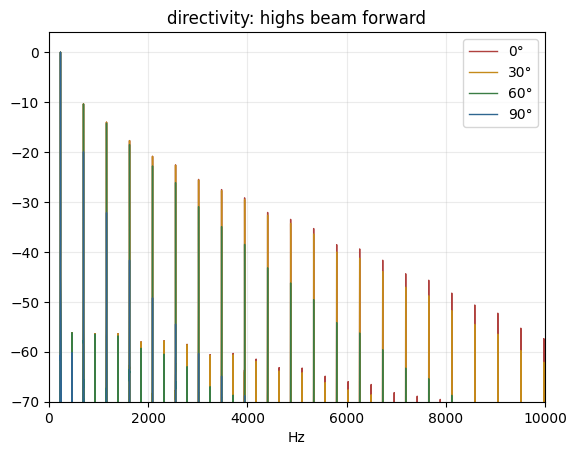

on-axis (0°):


off-axis (90°):


In [10]:
for a,col in [(0,'#b0413e'),(30,'#c58a1a'),(60,'#3a7d44'),(90,'#2f6690')]:
    f,S = spectrum_db(brass.directivity(note, a)); plt.plot(f,S,col,lw=1,label=f'{a}°')
plt.xlim(0,10000); plt.ylim(-70,4); plt.legend(); plt.grid(alpha=.25)
plt.title('directivity: highs beam forward'); plt.xlabel('Hz'); plt.show()
print('on-axis (0°):'); display(Audio(brass.directivity(note,0), rate=int(FS)))
print('off-axis (90°):'); display(Audio(brass.directivity(note,90), rate=int(FS)))